In [2]:
from nycschools import schools
import matplotlib.pyplot as plt

In [3]:
# See what's available in the schools module
dir(schools)

['__builtins__',
 '__cached__',
 '__demo_filename',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'clean_name',
 'config',
 'demo',
 'fuzz',
 'geo',
 'get_default_cols',
 'get_demo_2006',
 'get_demo_2013',
 'get_demo_2016',
 'get_demo_2022',
 'get_demo_2023',
 'get_demographics',
 'join_loc_data',
 'load',
 'load_hs_directory',
 'load_school_demographics',
 'math',
 'np',
 'os',
 'pd',
 're',
 'save_demographics',
 'school_type',
 'search',
 'set_school_level',
 'short_name',
 'str_count',
 'str_pct']

In [6]:
save_demo = schools.save_demographics()

loading: school_locations.geojson
[2005 2006 2007 2008 2009 2010 2011] {'non_binary_pct', 'non_binary_n'}
loading: school_locations.geojson
[2013 2014 2015 2016 2017] {'non_binary_pct', 'non_binary_n'}
loading: school_locations.geojson
[2016] {'non_binary_pct', 'non_binary_n'}
loading: school_locations.geojson
[2017 2018 2019 2020 2021] {'non_binary_pct', 'non_binary_n'}
loading: school_locations.geojson
[2020 2021 2022 2023 2024] {'asian_pct', 'asian_n'}
saving to: /home/teacher/projects/nyc_schools/data/school-demographics.csv


In [7]:
# Load demo data from 2023 to see the structure of school data
demo_data = schools.load_school_demographics()

loading: school-demographics.csv
/home/teacher/projects/nyc_schools/data/school-demographics.csv


In [8]:
demo_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32035 entries, 0 to 32034
Data columns (total 56 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   dbn                              32035 non-null  object 
 1   beds                             32035 non-null  int64  
 2   district                         32035 non-null  int64  
 3   geo_district                     32035 non-null  int64  
 4   boro                             32035 non-null  object 
 5   school_name                      32035 non-null  object 
 6   short_name                       32035 non-null  object 
 7   ay                               32035 non-null  int64  
 8   year                             32035 non-null  object 
 9   school_type                      32035 non-null  object 
 10  school_level                     32035 non-null  object 
 11  total_enrollment                 32035 non-null  int64  
 12  grade_3k          

In [9]:
# Check for missing values in the dataset
demo_data.isnull().sum()

dbn                                    0
beds                                   0
district                               0
geo_district                           0
boro                                   0
school_name                            0
short_name                             0
ay                                     0
year                                   0
school_type                            0
school_level                           0
total_enrollment                       0
grade_3k                               0
grade_pk                            6313
grade_k                             4941
grade_1                             4946
grade_2                             4988
grade_3                             5074
grade_4                             5127
grade_5                             5089
grade_6                             6563
grade_7                             6895
grade_8                             7021
grade_9                             7152
grade_10        

In [7]:
demo_data.describe()

,beds,district,geo_district,ay,total_enrollment,grade_3k,grade_pk,grade_k,grade_1,grade_2,...,missing_race_ethnicity_data_n,missing_race_ethnicity_data_pct,swd_n,swd_pct,ell_n,ell_pct,poverty_n,poverty_pct,eni,zip
count,9.363000e+03,9363.000000,9363.000000,9363.000000,9363.00000,9363.000000,9363.000000,9363.000000,9363.000000,9363.000000,...,9363.000000,9363.000000,9363.000000,9363.000000,9363.000000,9363.000000,9363.000000,9363.000000,9363.000000,9313.000000
mean,3.173717e+11,28.027235,15.731603,2021.010574,545.94788,4.354587,15.514685,37.952366,39.041867,39.256221,...,3.303535,0.005293,118.510093,0.241786,79.674036,0.148768,411.071238,0.780610,0.766987,10798.601417
std,5.828074e+10,26.789674,9.297468,1.413910,455.88917,21.261801,40.028230,43.924681,45.187985,45.855893,...,11.745118,0.014055,98.787433,0.157100,102.049641,0.144000,332.599818,0.187924,0.191162,529.563609
min,0.000000e+00,1.000000,0.000000,2019.000000,7.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.052941,0.058350,10001.000000
25%,3.207000e+11,10.000000,8.000000,2020.000000,298.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,63.000000,0.168188,20.000000,0.052632,219.000000,0.726572,0.687950,10452.000000
50%,3.314000e+11,20.000000,15.000000,2021.000000,440.00000,0.000000,0.000000,27.000000,27.000000,27.000000,...,0.000000,0.000000,94.000000,0.213139,45.000000,0.109326,336.000000,0.839041,0.830372,11105.000000
75%,3.332000e+11,30.000000,24.000000,2022.000000,642.00000,0.000000,27.000000,67.000000,69.000000,69.000000,...,2.000000,0.003945,138.000000,0.266602,100.000000,0.199261,491.000000,0.911215,0.907458,11231.000000
max,3.531009e+11,84.000000,32.000000,2023.000000,6040.00000,639.000000,1291.000000,261.000000,322.000000,312.000000,...,263.000000,0.276596,879.000000,1.000000,1258.000000,1.000000,3551.000000,0.960000,0.960000,11694.000000


In [10]:
demo_data.dtypes

dbn                                 object
beds                                 int64
district                             int64
geo_district                         int64
boro                                object
school_name                         object
short_name                          object
ay                                   int64
year                                object
school_type                         object
school_level                        object
total_enrollment                     int64
grade_3k                             int16
grade_pk                           float64
grade_k                            float64
grade_1                            float64
grade_2                            float64
grade_3                            float64
grade_4                            float64
grade_5                            float64
grade_6                            float64
grade_7                            float64
grade_8                            float64
grade_9    

In [11]:
# Check the overall shape and number of columns
print(f"Dataset shape: {demo_data.shape}")
print(f"Total columns: {len(demo_data.columns)}")

Dataset shape: (32035, 56)
Total columns: 56


In [10]:
# View all column names
demo_data.columns.tolist()

['dbn',
 'beds',
 'district',
 'geo_district',
 'boro',
 'school_name',
 'short_name',
 'ay',
 'year',
 'school_type',
 'school_level',
 'total_enrollment',
 'grade_3k',
 'grade_pk',
 'grade_k',
 'grade_1',
 'grade_2',
 'grade_3',
 'grade_4',
 'grade_5',
 'grade_6',
 'grade_7',
 'grade_8',
 'grade_9',
 'grade_10',
 'grade_11',
 'grade_12',
 'non_binary_n',
 'non_binary_pct',
 'female_n',
 'female_pct',
 'male_n',
 'male_pct',
 'asian_n',
 'asian_pct',
 'black_n',
 'black_pct',
 'hispanic_n',
 'hispanic_pct',
 'multi_racial_n',
 'multi_racial_pct',
 'native_american_n',
 'native_american_pct',
 'white_n',
 'white_pct',
 'missing_race_ethnicity_data_n',
 'missing_race_ethnicity_data_pct',
 'swd_n',
 'swd_pct',
 'ell_n',
 'ell_pct',
 'poverty_n',
 'poverty_pct',
 'eni',
 'clean_name',
 'zip']

In [11]:
# Check for missing values in each column
demo_data.isnull().sum()

dbn                                   0
beds                                  0
district                              0
geo_district                          0
boro                                  0
school_name                           0
short_name                            0
ay                                    0
year                                  0
school_type                           0
school_level                          0
total_enrollment                      0
grade_3k                              0
grade_pk                              0
grade_k                               0
grade_1                               0
grade_2                               0
grade_3                               0
grade_4                               0
grade_5                               0
grade_6                               0
grade_7                               0
grade_8                               0
grade_9                               0
grade_10                              0


In [12]:
demo_data.describe()

,beds,district,geo_district,ay,total_enrollment,grade_3k,grade_pk,grade_k,grade_1,grade_2,...,missing_race_ethnicity_data_n,missing_race_ethnicity_data_pct,swd_n,swd_pct,ell_n,ell_pct,poverty_n,poverty_pct,eni,zip
count,9.363000e+03,9363.000000,9363.000000,9363.000000,9363.00000,9363.000000,9363.000000,9363.000000,9363.000000,9363.000000,...,9363.000000,9363.000000,9363.000000,9363.000000,9363.000000,9363.000000,9363.000000,9363.000000,9363.000000,9313.000000
mean,3.173717e+11,28.027235,15.731603,2021.010574,545.94788,4.354587,15.514685,37.952366,39.041867,39.256221,...,3.303535,0.005293,118.510093,0.241786,79.674036,0.148768,411.071238,0.780610,0.766987,10798.601417
std,5.828074e+10,26.789674,9.297468,1.413910,455.88917,21.261801,40.028230,43.924681,45.187985,45.855893,...,11.745118,0.014055,98.787433,0.157100,102.049641,0.144000,332.599818,0.187924,0.191162,529.563609
min,0.000000e+00,1.000000,0.000000,2019.000000,7.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.052941,0.058350,10001.000000
25%,3.207000e+11,10.000000,8.000000,2020.000000,298.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,63.000000,0.168188,20.000000,0.052632,219.000000,0.726572,0.687950,10452.000000
50%,3.314000e+11,20.000000,15.000000,2021.000000,440.00000,0.000000,0.000000,27.000000,27.000000,27.000000,...,0.000000,0.000000,94.000000,0.213139,45.000000,0.109326,336.000000,0.839041,0.830372,11105.000000
75%,3.332000e+11,30.000000,24.000000,2022.000000,642.00000,0.000000,27.000000,67.000000,69.000000,69.000000,...,2.000000,0.003945,138.000000,0.266602,100.000000,0.199261,491.000000,0.911215,0.907458,11231.000000
max,3.531009e+11,84.000000,32.000000,2023.000000,6040.00000,639.000000,1291.000000,261.000000,322.000000,312.000000,...,263.000000,0.276596,879.000000,1.000000,1258.000000,1.000000,3551.000000,0.960000,0.960000,11694.000000


In [13]:
demo_data.dtypes

dbn                                    str
beds                                 int64
district                             int64
geo_district                         int64
boro                                   str
school_name                            str
short_name                             str
ay                                   int64
year                                   str
school_type                         object
school_level                           str
total_enrollment                     int64
grade_3k                             int64
grade_pk                             int64
grade_k                              int64
grade_1                              int64
grade_2                              int64
grade_3                              int64
grade_4                              int64
grade_5                              int64
grade_6                              int64
grade_7                              int64
grade_8                              int64
grade_9    

In [14]:
# Get dataset dimensions and memory info
print(f"Shape: {demo_data.shape}")
print(f"\nMemory usage:\n{demo_data.memory_usage(deep=True)}")

Shape: (9363, 56)

Memory usage:
Index                                 132
dbn                                131082
beds                                74904
district                            74904
geo_district                        74904
boro                               142890
school_name                        350785
short_name                         112824
ay                                  74904
year                               140445
school_type                        538516
school_level                       135723
total_enrollment                    74904
grade_3k                            74904
grade_pk                            74904
grade_k                             74904
grade_1                             74904
grade_2                             74904
grade_3                             74904
grade_4                             74904
grade_5                             74904
grade_6                             74904
grade_7                             74904
g

In [15]:
# Total memory usage in MB
total_memory_mb = demo_data.memory_usage(deep=True).sum() / 1024**2
print(f"Total memory usage: {total_memory_mb:.2f} MB")

Total memory usage: 5.21 MB


In [16]:
# Check for missing values
print(demo_data.isnull().sum().sort_values(ascending=False))

non_binary_pct                     5589
non_binary_n                       5589
zip                                  50
dbn                                   0
boro                                  0
beds                                  0
district                              0
geo_district                          0
year                                  0
school_type                           0
school_level                          0
total_enrollment                      0
grade_3k                              0
grade_pk                              0
grade_k                               0
grade_1                               0
grade_2                               0
grade_3                               0
grade_4                               0
grade_5                               0
grade_6                               0
school_name                           0
short_name                            0
ay                                    0
grade_9                               0


In [17]:
# Examine the columns with missing values
print("non_binary_pct missing:", demo_data['non_binary_pct'].isnull().sum())
print("non_binary_n missing:", demo_data['non_binary_n'].isnull().sum())
print("zip missing:", demo_data['zip'].isnull().sum())
print("\nData type and sample values:")
print(demo_data[['non_binary_pct', 'non_binary_n', 'zip']].head(10))

non_binary_pct missing: 5589
non_binary_n missing: 5589
zip missing: 50

Data type and sample values:
   non_binary_pct  non_binary_n      zip
0             NaN           NaN  10009.0
1             NaN           NaN  10009.0
2             NaN           NaN  10009.0
3             0.0           0.0  10009.0
4             0.0           0.0  10009.0
5             NaN           NaN  10002.0
6             NaN           NaN  10002.0
7             NaN           NaN  10002.0
8             0.0           0.0  10002.0
9             0.0           0.0  10002.0


In [18]:
# Calculate missing percentage for each column
missing_pct = (demo_data.isnull().sum() / len(demo_data) * 100).sort_values(ascending=False)
print(missing_pct.head(10))

non_binary_pct    59.692406
non_binary_n      59.692406
zip                0.534017
dbn                0.000000
boro               0.000000
beds               0.000000
district           0.000000
geo_district       0.000000
year               0.000000
school_type        0.000000
dtype: float64


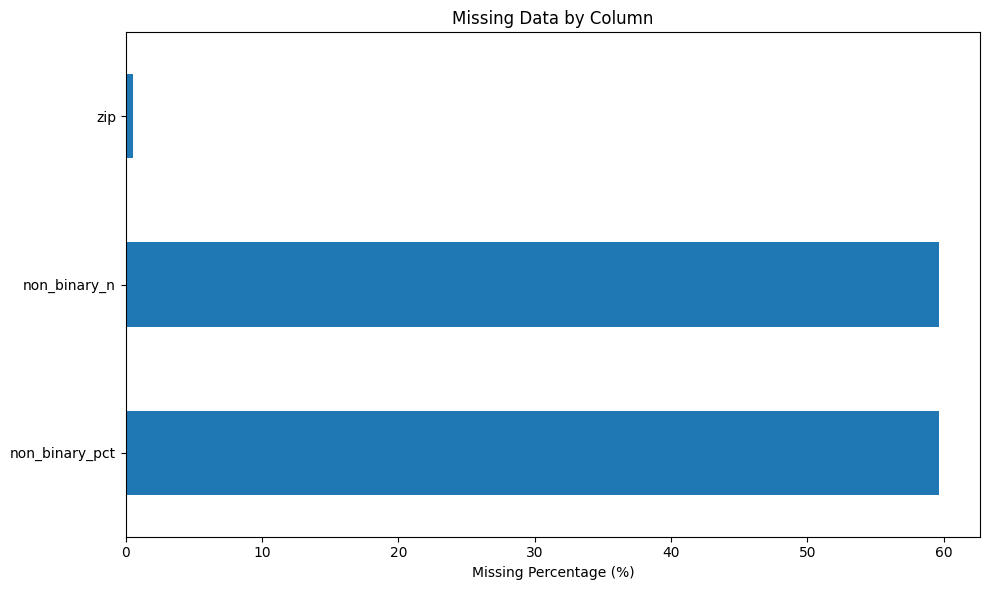

In [21]:
# Visualize missing percentage for columns with missing data
missing_pct[missing_pct > 0].plot(kind='barh', figsize=(10, 6))
plt.xlabel('Missing Percentage (%)')
plt.title('Missing Data by Column')
plt.tight_layout()
plt.show()